In [1]:
# ╔═════════════════════════════════════════════════════════════╗
# ║  [Step 1.1] Google Colab Environment Setup                   ║
# ╚═════════════════════════════════════════════════════════════╝

# Check GPU configuration
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Current device: {device}")

if torch.cuda.is_available():
    print(f"✓ GPU model: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    torch.cuda.empty_cache()
    print("✓ GPU cache cleared!")
print()

✓ Current device: cuda
✓ GPU model: Tesla T4
✓ GPU memory: 15.64 GB
✓ GPU cache cleared!



In [2]:
# ╔═════════════════════════════════════════════════════════════╗
# ║  [Step 1.2] Import Required Python Libraries                 ║
# ╚═════════════════════════════════════════════════════════════╝

# Core data processing libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# PyTorch deep learning libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Display settings
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ All libraries imported!")
print()

# ╔═════════════════════════════════════════════════════════════╗
# ║  [Step 1.3] Set Random Seeds (ensure reproducibility)        ║
# ╚═════════════════════════════════════════════════════════════╝

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

print(f"✓ Random seed set to {seed}")
print("  Every run will produce identical results.")
print()

✓ All libraries imported!

✓ Random seed set to 42
  Every run will produce identical results.



In [3]:
# ╔═════════════════════════════════════════════════════════════╗
# ║  [Step 1.4] Data Loading Function                            ║
# ╚═════════════════════════════════════════════════════════════╝

def load_data(file_path):
    """
    Read NASA C-MAPSS dataset (.txt format)

    Data structure:
    ┌─────────────────────────────────────────────────┐
    │ Col  │ Name              │ Description          │
    ├─────────────────────────────────────────────────┤
    │ 1    │ unit_nr           │ Engine ID (1-100)    │
    │ 2    │ time_cycles       │ Operational cycles   │
    │ 3-5  │ setting_1-3       │ Operational settings │
    │ 6-26 │ s_1 ~ s_21        │ Sensor readings      │
    └─────────────────────────────────────────────────┘

    Args:
        file_path (str): Path to data file

    Returns:
        df (pd.DataFrame): DataFrame with column names
    """

    # Define column names
    index_names = ['unit_nr', 'time_cycles']
    setting_names = ['setting_1', 'setting_2', 'setting_3']
    sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
    col_names = index_names + setting_names + sensor_names

    # Read data (sep='\s+' handles any whitespace/tab delimiter)
    df = pd.read_csv(file_path, sep='\s+', header=None, names=col_names)

    return df

print("✓ Data loading function defined")
print()

✓ Data loading function defined



In [4]:
def preprocess_data(df, exclude_sensors=None, rul_max=120):
    """
    Three key preprocessing steps:

    Step 1: Compute RUL (Remaining Useful Life)
        For each engine:
          - Find max operating cycles = engine lifespan
          - RUL = max_cycles - current_cycle
          - Cap RUL at rul_max (standard CMAPSS practice)

    Step 2: Remove low-variance sensors
        Some sensors show no degradation signal throughout the run
        — like a broken instrument reading a constant value.

    Step 3: Min-Max normalization
        Problem: sensors have different units
          - Temperature: 0-1000 °C
          - Pressure: 0-50 bar
          - Speed: 0-10000 RPM
        Solution: scale all features to [0, 1]
          new_val = (val - min) / (max - min)
        Effect: all features are treated equally
    """

    if exclude_sensors is None:
        # Empirically identified sensors with near-zero variance
        exclude_sensors = ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']

    print("🧹 [Data Preprocessing]")
    print(f"   Raw data shape: {df.shape}")

    # ★ Step 1: Compute RUL
    print("   ⚙️  [Step 1] Computing RUL...")
    max_cycle = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    max_cycle.columns = ['unit_nr', 'max']
    df = df.merge(max_cycle, on='unit_nr', how='left')
    df['RUL'] = df['max'] - df['time_cycles']
    # Cap RUL — standard CMAPSS benchmark practice (Heimes 2008)
    df['RUL'] = df['RUL'].clip(upper=rul_max)
    df.drop('max', axis=1, inplace=True)

    # ★ Step 2: Drop low-variance sensors
    print(f"   ⚙️  [Step 2] Dropping {len(exclude_sensors)} uninformative sensors...")
    df.drop(exclude_sensors, axis=1, inplace=True)

    # ★ Step 3: Normalize features
    print("   ⚙️  [Step 3] Normalizing features to [0, 1]...")
    scaler = MinMaxScaler()
    feature_cols = [c for c in df.columns if c not in ['unit_nr', 'time_cycles', 'RUL']]
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

    print(f"   ✓ Processed data shape: {df.shape}")
    print(f"   ✓ Features retained: {len(feature_cols)}")
    print()

    return df, feature_cols, scaler

print("✓ Preprocessing function defined")
print()

✓ Preprocessing function defined



In [5]:
def create_sequences(df, seq_length, feature_cols):
    """
    Generate sliding-window time series samples.

    Args:
        df:           Preprocessed DataFrame
        seq_length:   Window size (number of historical time steps)
        feature_cols: Feature column names

    Returns:
        X:        Input array,  shape (n_samples, seq_length, n_features)
        y:        Label array,  shape (n_samples,)
        unit_ids: Engine ID for each sample
    """

    X, y, unit_ids = [], [], []

    for unit_id in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit_id]

        X_unit = unit_data[feature_cols].values   # shape: (n_cycles, n_features)
        y_unit = unit_data['RUL'].values          # shape: (n_cycles,)

        # Sliding window over the engine's time series
        for start in range(len(X_unit) - seq_length):
            end = start + seq_length

            X.append(X_unit[start:end])    # shape: (seq_length, n_features)
            y.append(y_unit[end - 1])      # RUL at the last step of the window
            unit_ids.append(unit_id)

    return np.array(X), np.array(y), np.array(unit_ids)

print("✓ Sequence generation function defined")
print()

# ╔═════════════════════════════════════════════════════════════╗
# ║  Dataset Split Function                                      ║
# ╚═════════════════════════════════════════════════════════════╝

def split_dataset(X, y, unit_ids, val_ratio=0.2, test_ratio=0.1):
    """
    Split data into train / validation / test sets.

    Splits by engine ID (not random row shuffle) to avoid
    data leakage between sets — the correct approach for
    time series with multiple entities.
    """

    unique_units = np.unique(unit_ids)
    n_units = len(unique_units)

    # Compute split sizes
    n_val = int(n_units * val_ratio)
    n_test = int(n_units * test_ratio)
    n_train = n_units - n_val - n_test

    # Assign engines to each split
    train_units = unique_units[:n_train]
    val_units   = unique_units[n_train:n_train + n_val]
    test_units  = unique_units[n_train + n_val:]

    # Boolean masks
    train_mask = np.isin(unit_ids, train_units)
    val_mask   = np.isin(unit_ids, val_units)
    test_mask  = np.isin(unit_ids, test_units)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val,   y_val   = X[val_mask],   y[val_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

print("✓ Dataset split function defined")
print()

✓ Sequence generation function defined

✓ Dataset split function defined



In [6]:
class GRURULPredictor(nn.Module):
    """
    GRU neural network for RUL prediction.

    Args:
        input_dim:  Number of input features (15 sensors)
        hidden_dim: Hidden state dimension (64) — model "memory capacity"
        num_layers: Number of stacked GRU layers (2)
        output_dim: Output dimension (1) — single RUL value
        dropout:    Dropout rate (0.3) — regularization

    Forward pass:
        1. Initialize hidden state to zeros
        2. GRU processes the sequence step-by-step
        3. Extract the last hidden state
        4. Map through a fully-connected layer to output RUL
    """

    def __init__(self, input_dim=15, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.3):
        super(GRURULPredictor, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # ★ GRU encoder
        # batch_first=True: input shape (batch_size, seq_length, input_dim)
        # dropout applied between GRU layers to prevent overfitting
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # ★ Fully-connected output head
        self.fc = nn.Linear(hidden_dim, output_dim)

        # ★ Weight initialization
        self._init_weights()

    def _init_weights(self):
        """
        Xavier / orthogonal initialization.
        Prevents vanishing/exploding gradients at the start of training.
        """
        for name, param in self.gru.named_parameters():
            if 'weight_ih' in name:    # input-to-hidden weights
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:  # hidden-to-hidden weights
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.1)

    def forward(self, x):
        """
        Forward pass.

        Args:
            x: shape (batch_size, seq_length, input_dim)
               e.g. (64, 30, 15)

        Returns:
            out: shape (batch_size, output_dim)
                 e.g. (64, 1)
        """

        # 1️⃣ Initialize hidden state — shape: (num_layers, batch_size, hidden_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # 2️⃣ Run GRU over the sequence
        # out shape: (batch_size, seq_length, hidden_dim)
        out, _ = self.gru(x, h0)

        # 3️⃣ Take the last time step's hidden state
        # shape: (batch_size, hidden_dim)
        last_hidden = out[:, -1, :]

        # 4️⃣ Project to output dimension
        out = self.fc(last_hidden)  # shape: (batch_size, 1)

        return out

print("✓ GRU model defined")
print()

✓ GRU model defined



In [7]:
def nasa_scoring_function(predictions, actuals):
    """
    NASA asymmetric scoring function (IEEE PHM 2014).

    Penalizes late predictions (predicted RUL > true RUL) more
    severely than early predictions, reflecting the higher safety
    risk of under-maintenance versus over-maintenance.

    Lower score is better; ideal score is 0.
    """
    predictions = predictions.flatten()
    actuals     = actuals.flatten()

    score = 0
    for pred, actual in zip(predictions, actuals):
        d = pred - actual

        if d < 0:   # Early prediction (conservative) — lighter penalty
            score += np.exp(-d / 10) - 1
        else:       # Late prediction (dangerous)     — heavier penalty
            score += np.exp(d / 13) - 1

    return score

def calculate_metrics(predictions, actuals):
    """
    Compute multiple RUL prediction evaluation metrics.
    """
    predictions = predictions.flatten()
    actuals     = actuals.flatten()

    # 1. MAE — Mean Absolute Error
    mae = np.mean(np.abs(predictions - actuals))

    # 2. RMSE — Root Mean Squared Error
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))

    # 3. R² — Coefficient of determination
    ss_res = np.sum((actuals - predictions) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    r2_score = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    # 4. NASA Score
    nasa_score = nasa_scoring_function(predictions, actuals)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2_score,
        'NASA_Score': nasa_score
    }

print("✓ Evaluation metric functions defined")
print()

✓ Evaluation metric functions defined



In [8]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    """
    Train the model for one epoch.
    """
    model.train()
    total_loss = 0

    for X_batch, y_batch in tqdm(train_loader, desc="[Training]", leave=False):
        # 1️⃣ Move data to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 2️⃣ Forward pass
        predictions = model(X_batch)

        # 3️⃣ Compute loss
        loss = criterion(predictions, y_batch)

        # 4️⃣ Clear old gradients (must be done before backward)
        optimizer.zero_grad()

        # 5️⃣ Backward pass
        loss.backward()

        # 6️⃣ Gradient descent step
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def evaluate(model, data_loader, criterion, device):
    """
    Evaluate model performance on a given data loader.
    """
    model.eval()  # Disable dropout etc.
    total_loss = 0
    all_predictions = []
    all_actuals = []

    with torch.no_grad():  # No gradient computation during evaluation
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item()
            all_predictions.append(predictions.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())

    avg_loss        = total_loss / len(data_loader)
    all_predictions = np.concatenate(all_predictions)
    all_actuals     = np.concatenate(all_actuals)

    metrics = calculate_metrics(all_predictions, all_actuals)

    return avg_loss, metrics, all_predictions, all_actuals

print("✓ Training and evaluation functions defined")
print()

✓ Training and evaluation functions defined



In [10]:
# ╔═════════════════════════════════════════════════════════════╗
# ║  [Main Program] Full Training Pipeline                       ║
# ║  Estimated runtime: 3-10 minutes (depends on GPU)           ║
# ╚═════════════════════════════════════════════════════════════╝

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Configuration]
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

config = {
    # 📁 Data file paths (adjust to your Google Drive layout)
    'train_data_path': '/content/Bayesian Machine Learning/train_FD001.txt',
    'test_data_path':  '/content/Bayesian Machine Learning/test_FD001.txt',
    'rul_data_path':   '/content/Bayesian Machine Learning/RUL_FD001.txt',

    # 🔧 Sequence parameters
    'seq_length': 30,           # Historical window size

    # 📦 Batch / training parameters
    'batch_size':  64,          # Samples per batch
    'num_epochs':  100,          # Training iterations

    # 🧠 Model architecture
    'input_dim':  None,         # Set at runtime from data
    'hidden_dim': 64,           # GRU hidden state size
    'num_layers': 2,            # Number of stacked GRU layers
    'dropout':    0.3,          # Dropout rate

    # 🎓 Optimizer
    'learning_rate': 0.001,     # Adam learning rate
    'weight_decay':  1e-5,      # L2 regularization strength

    # 📊 Dataset split
    'val_ratio':  0.2,          # Fraction used for validation
    'test_ratio': 0.1,          # Fraction used for testing
}

print("=" * 70)
print("🚀 [RUL Prediction System] Initializing...")
print("=" * 70)
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 1: Load data
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("📖 [Step 1] Loading data...")
try:
    train_df = load_data(config['train_data_path'])
    print(f"   ✓ Loaded {train_df['unit_nr'].nunique()} engines from training set")
    print(f"   ✓ Total rows: {len(train_df)}")
except FileNotFoundError:
    print("   ✗ Error: Data file not found!")
    print(f"   Path: {config['train_data_path']}")
    print("   Please check:")
    print("   1. File is uploaded to Google Drive")
    print("   2. Path and filename are correct (case-sensitive)")

print()

print("🧹 [Step 2] Preprocessing data...")
processed_df, features, scaler = preprocess_data(train_df)
config['input_dim'] = len(features)  # Update feature dimension in config

print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 2: Generate time series sequences
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("🔗 [Step 3] Generating sequences...")
X, y, unit_ids = create_sequences(
    processed_df,
    config['seq_length'],
    features
)

print(f"   ✓ Total sequences generated: {len(X)}")
print(f"   ✓ X shape: {X.shape}")
print(f"   ✓ y shape: {y.shape}")
print(f"   ✓ unit_ids shape: {unit_ids.shape}")
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 3: Split dataset
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("🔀 [Step 4] Splitting dataset...")
(X_train, y_train), (X_val, y_val), (X_test, y_test) = split_dataset(
    X, y, unit_ids,
    val_ratio=config['val_ratio'],
    test_ratio=config['test_ratio']
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print(f"   ✓ Train set: {X_train_tensor.shape}")
print(f"   ✓ Val   set: {X_val_tensor.shape}")
print(f"   ✓ Test  set: {X_test_tensor.shape}")
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 4: Create DataLoaders
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("📦 [Step 5] Creating data loaders...")

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=config['batch_size'],
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=config['batch_size'],
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=config['batch_size'],
    shuffle=False
)

print(f"   ✓ Train batches: {len(train_loader)}")
print(f"   ✓ Val   batches: {len(val_loader)}")
print(f"   ✓ Test  batches: {len(test_loader)}")
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 5: Initialize model, optimizer, loss function
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("🧠 [Step 6] Initializing model...")

model = GRURULPredictor(
    input_dim=config['input_dim'],
    hidden_dim=config['hidden_dim'],
    num_layers=config['num_layers'],
    dropout=config['dropout']
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   ✓ Total parameters:     {total_params:,}")
print(f"   ✓ Trainable parameters: {trainable_params:,}")
print()

# Adam optimizer with L2 regularization
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

criterion = nn.MSELoss()

print(f"✓ Optimizer: Adam (lr={config['learning_rate']})")
print(f"✓ Loss function: MSE Loss")
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 6: Training loop
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 70)
print("🎓 [Training]")
print("=" * 70)

history = {
    'train_loss': [], 'val_loss': [],
    'val_mae': [], 'val_rmse': [], 'val_r2': [], 'val_nasa_score': []
}

best_val_loss    = float('inf')
best_model_state = None
patience         = 10
patience_counter = 0

for epoch in range(config['num_epochs']):
    train_loss            = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, metrics, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(metrics['MAE'])
    history['val_rmse'].append(metrics['RMSE'])
    history['val_r2'].append(metrics['R2'])
    history['val_nasa_score'].append(metrics['NASA_Score'])

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping triggered (patience={patience})")
            model.load_state_dict(best_model_state)
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"NASA Score: {metrics['NASA_Score']:.2f} | "
              f"R²: {metrics['R2']:.4f}")

print()
print("=" * 70)
print("✓ Training complete!")
print("=" * 70)
print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Step 7: Final evaluation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("📊 [Step 7] Final test evaluation...")

test_loss, test_metrics, test_pred, test_actual = evaluate(
    model, test_loader, criterion, device
)

print(f"   ✓ Test MSE Loss:   {test_loss:.6f}")
print(f"   ✓ Test MAE:        {test_metrics['MAE']:.4f} cycles")
print(f"   ✓ Test RMSE:       {test_metrics['RMSE']:.4f} cycles")
print(f"   ✓ Test R²:         {test_metrics['R2']:.4f}")
print(f"   ✓ Test NASA Score: {test_metrics['NASA_Score']:.2f}")
print()
print(f"   📈 Prediction range: [{test_pred.min():.2f}, {test_pred.max():.2f}]")
print(f"   📉 True RUL range:   [{test_actual.min():.2f}, {test_actual.max():.2f}]")
print()

🚀 [RUL Prediction System] Initializing...

📖 [Step 1] Loading data...
   ✓ Loaded 100 engines from training set
   ✓ Total rows: 20631

🧹 [Step 2] Preprocessing data...
🧹 [Data Preprocessing]
   Raw data shape: (20631, 26)
   ⚙️  [Step 1] Computing RUL...
   ⚙️  [Step 2] Dropping 6 uninformative sensors...
   ⚙️  [Step 3] Normalizing features to [0, 1]...
   ✓ Processed data shape: (20631, 21)
   ✓ Features retained: 18


🔗 [Step 3] Generating sequences...
   ✓ Total sequences generated: 17631
   ✓ X shape: (17631, 30, 18)
   ✓ y shape: (17631,)
   ✓ unit_ids shape: (17631,)

🔀 [Step 4] Splitting dataset...
   ✓ Train set: torch.Size([12030, 30, 18])
   ✓ Val   set: torch.Size([3650, 30, 18])
   ✓ Test  set: torch.Size([1951, 30, 18])

📦 [Step 5] Creating data loaders...
   ✓ Train batches: 188
   ✓ Val   batches: 58
   ✓ Test  batches: 31

🧠 [Step 6] Initializing model...
   ✓ Total parameters:     41,153
   ✓ Trainable parameters: 41,153

✓ Optimizer: Adam (lr=0.001)
✓ Loss function:

Epoch   5/100 | Train Loss: 2436.1865 | Val Loss: 2364.4523 | NASA Score: 1188767.00 | R²: -0.4875


Epoch  10/100 | Train Loss: 1614.1013 | Val Loss: 1690.4328 | NASA Score: 212523.84 | R²: -0.0270


Epoch  15/100 | Train Loss: 1560.4069 | Val Loss: 1230.3438 | NASA Score: 120302.83 | R²: 0.2422


Epoch  20/100 | Train Loss: 193.6524 | Val Loss: 215.6464 | NASA Score: 18439.45 | R²: 0.8617


Epoch  25/100 | Train Loss: 150.4462 | Val Loss: 130.3570 | NASA Score: 7951.35 | R²: 0.9165


Epoch  30/100 | Train Loss: 142.6852 | Val Loss: 132.2936 | NASA Score: 8599.59 | R²: 0.9152


Epoch  35/100 | Train Loss: 138.6311 | Val Loss: 127.1328 | NASA Score: 7530.85 | R²: 0.9185


Epoch  40/100 | Train Loss: 133.2129 | Val Loss: 143.5936 | NASA Score: 10294.44 | R²: 0.9080



⚠️  Early stopping triggered (patience=10)

✓ Training complete!

📊 [Step 7] Final test evaluation...
   ✓ Test MSE Loss:   161.695112
   ✓ Test MAE:        9.2366 cycles
   ✓ Test RMSE:       12.8109 cycles
   ✓ Test R²:         0.8961
   ✓ Test NASA Score: 5892.54

   📈 Prediction range: [1.89, 119.48]
   📉 True RUL range:   [1.00, 120.00]



📈 [Step 8] Generating evaluation plots...

   ✓ Plot saved as 'model_evaluation_results.png'


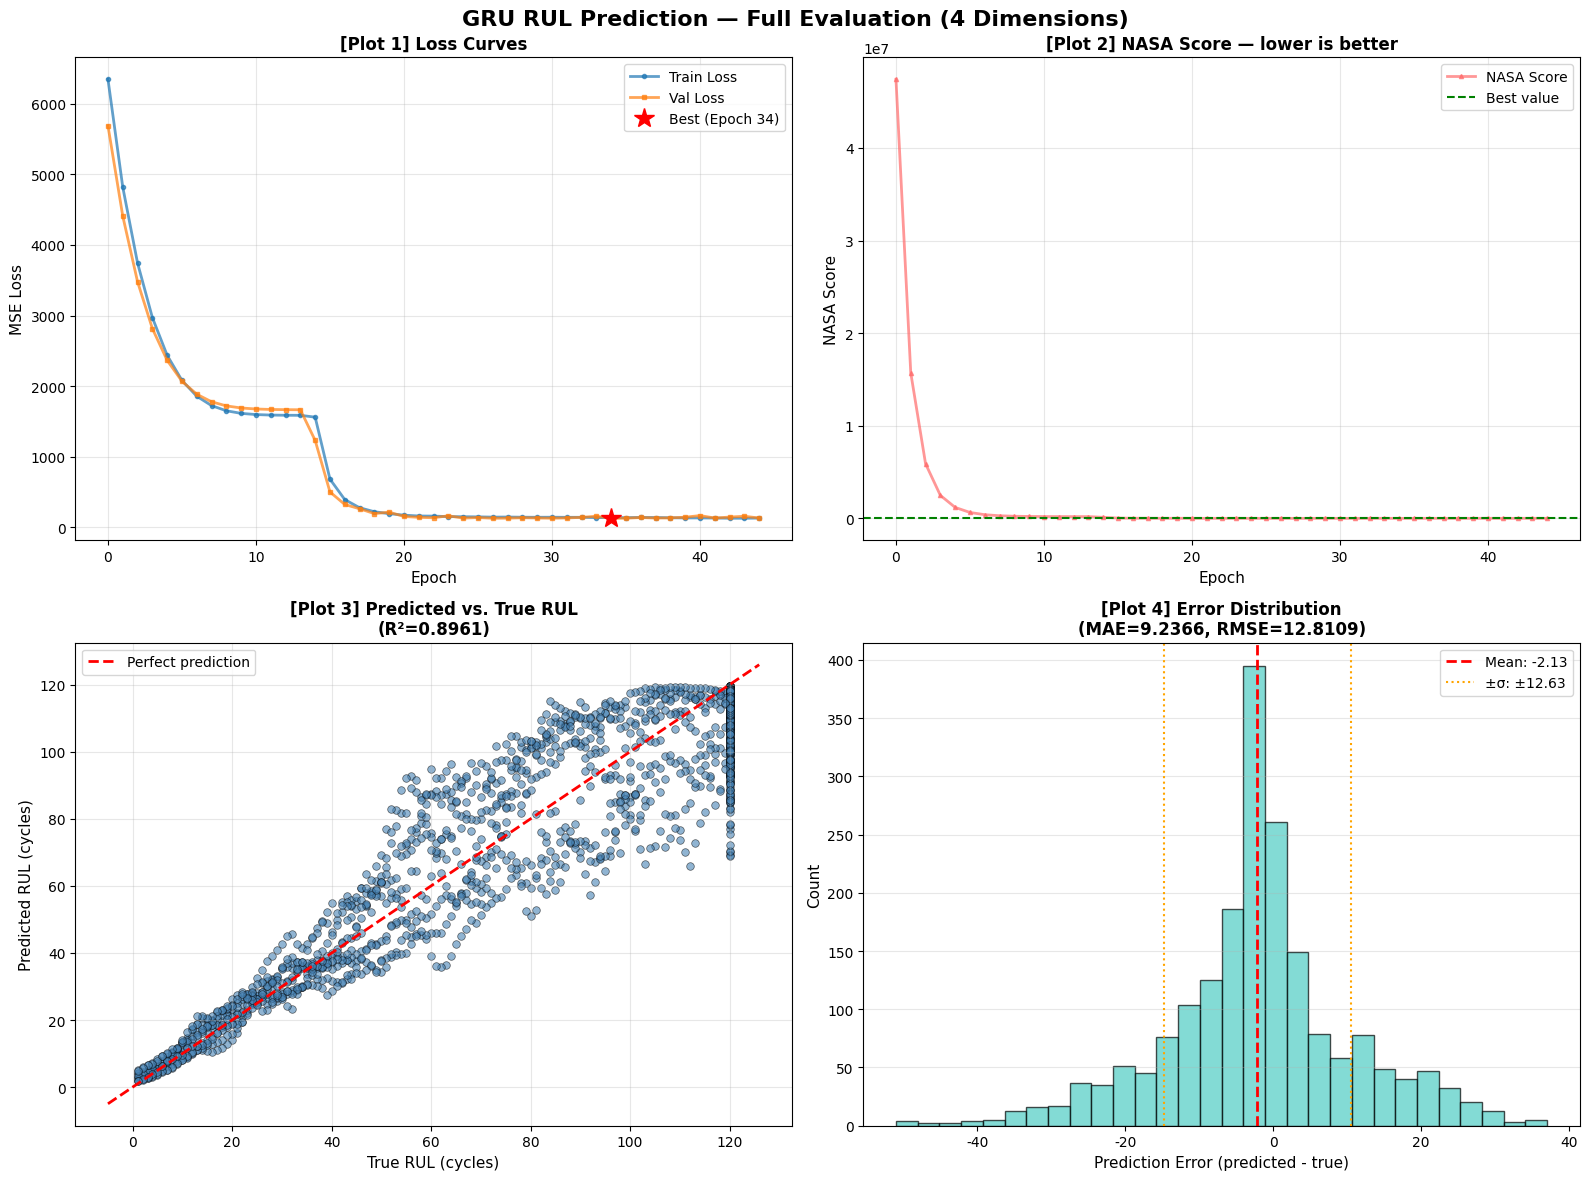


📋 [Sample Prediction Results]

Sample # | True RUL | Pred RUL | Abs Error | Rel Error
---------------------------------------------------------
   305   |   111.0  |    70.1  |    40.9   |   36.8%
   307   |   109.0  |    81.0  |    28.0   |   25.7%
   432   |   109.0  |   116.3  |     7.3   |    6.7%
   599   |   120.0  |   115.6  |     4.4   |    3.7%
  1089   |   120.0  |   117.5  |     2.5   |    2.1%
  1406   |    94.0  |   107.5  |    13.5   |   14.4%
  1467   |    33.0  |    37.2  |     4.2   |   12.8%
  1580   |    46.0  |    55.8  |     9.8   |   21.3%
  1615   |    11.0  |    13.5  |     2.5   |   22.9%
  1905   |    46.0  |    53.7  |     7.7   |   16.8%



In [11]:
print("📈 [Step 8] Generating evaluation plots...")
print()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GRU RUL Prediction — Full Evaluation (4 Dimensions)', fontsize=16, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Plot 1] Training & validation loss curves
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

axes[0, 0].plot(history['train_loss'], label='Train Loss',
                linewidth=2, marker='o', markersize=3, alpha=0.7)
axes[0, 0].plot(history['val_loss'], label='Val Loss',
                linewidth=2, marker='s', markersize=3, alpha=0.7)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('MSE Loss', fontsize=11)
axes[0, 0].set_title('[Plot 1] Loss Curves', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Mark the best epoch
best_epoch = np.argmin(history['val_loss'])
axes[0, 0].plot(best_epoch, history['val_loss'][best_epoch], 'r*', markersize=15,
               label=f'Best (Epoch {best_epoch})')
axes[0, 0].legend(loc='upper right', fontsize=10)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Plot 2] NASA score trend
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

axes[0, 1].plot(history['val_nasa_score'], label='NASA Score',
               linewidth=2, marker='^', markersize=3, color='#FF6B6B', alpha=0.7)
axes[0, 1].axhline(y=min(history['val_nasa_score']), color='green',
                   linestyle='--', linewidth=1.5, label='Best value')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('NASA Score', fontsize=11)
axes[0, 1].set_title('[Plot 2] NASA Score — lower is better', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Plot 3] Predicted vs. true RUL (scatter)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

axes[1, 0].scatter(test_actual, test_pred, alpha=0.6, s=30,
                  edgecolors='black', linewidth=0.5, color='steelblue')

# Perfect prediction line (45-degree diagonal)
min_val = min(test_actual.min(), test_pred.min())
max_val = max(test_actual.max(), test_pred.max())
margin  = (max_val - min_val) * 0.05
axes[1, 0].plot([min_val - margin, max_val + margin],
               [min_val - margin, max_val + margin],
               'r--', linewidth=2, label='Perfect prediction')

axes[1, 0].set_xlabel('True RUL (cycles)', fontsize=11)
axes[1, 0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[1, 0].set_title(f'[Plot 3] Predicted vs. True RUL\n(R²={test_metrics["R2"]:.4f})',
                    fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='upper left', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Plot 4] Prediction error distribution
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

errors      = test_pred.flatten() - test_actual.flatten()
mean_error  = errors.mean()
std_error   = errors.std()

axes[1, 1].hist(errors, bins=30, alpha=0.7, color='#4ECDC4', edgecolor='black', linewidth=1)
axes[1, 1].axvline(mean_error, color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {mean_error:.2f}')
axes[1, 1].axvline(mean_error + std_error, color='orange', linestyle=':', linewidth=1.5,
                  label=f'±σ: ±{std_error:.2f}')
axes[1, 1].axvline(mean_error - std_error, color='orange', linestyle=':', linewidth=1.5)

axes[1, 1].set_xlabel('Prediction Error (predicted - true)', fontsize=11)
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title(f'[Plot 4] Error Distribution\n(MAE={test_metrics["MAE"]:.4f}, RMSE={test_metrics["RMSE"]:.4f})',
                    fontsize=12, fontweight='bold')
axes[1, 1].legend(loc='upper right', fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_evaluation_results.png', dpi=150, bbox_inches='tight')
print("   ✓ Plot saved as 'model_evaluation_results.png'")
plt.show()

print()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Sample prediction detail
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("📋 [Sample Prediction Results]")
print()
print("Sample # | True RUL | Pred RUL | Abs Error | Rel Error")
print("-" * 57)

sample_indices = np.random.choice(len(test_actual), min(10, len(test_actual)), replace=False)
for idx in sorted(sample_indices):
    actual    = test_actual[idx, 0]
    pred      = test_pred[idx, 0]
    abs_error = abs(pred - actual)
    rel_error = (abs_error / actual * 100) if actual != 0 else 0
    print(f"  {idx:4d}   |  {actual:6.1f}  |  {pred:6.1f}  |  {abs_error:6.1f}   | {rel_error:6.1f}%")

print()